In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/ml projekt/WELFake_Dataset.csv')
print(df.head())

# Sprawdzamy typy danych i braki
print(df.info())

# Sprawdzamyczy są jakieś brakujące wartości
print(df.isnull().sum())

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null

label
1    37106
0    35028
Name: count, dtype: int64


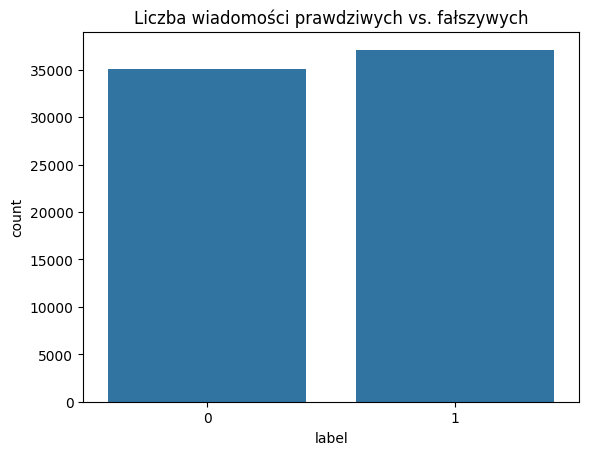

In [3]:
# Sprawdzenie liczby wiadomości w każdej kategorii
print(df['label'].value_counts())

# Wizualizacja dystrybucji
sns.countplot(x='label', data=df)
plt.title('Liczba wiadomości prawdziwych vs. fałszywych')
plt.show()

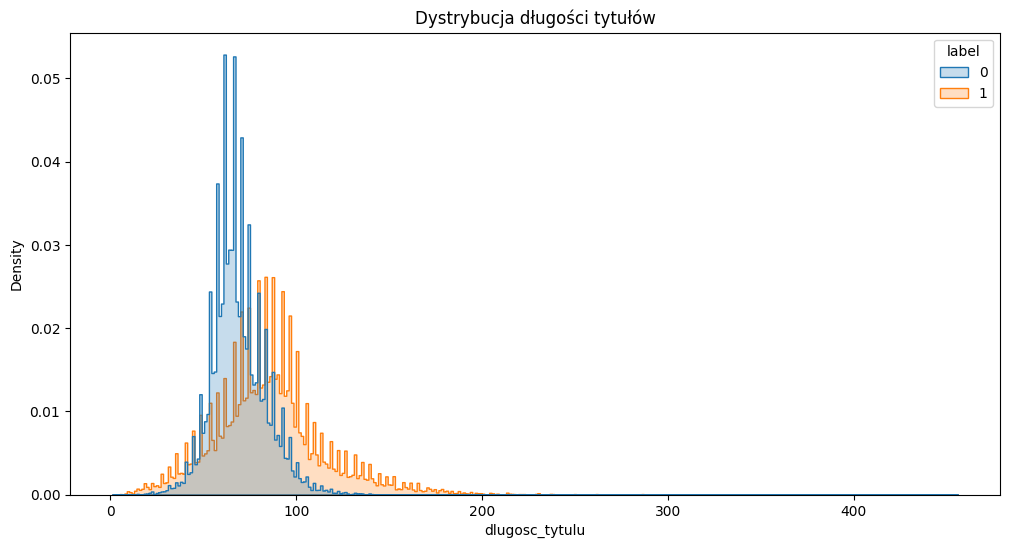

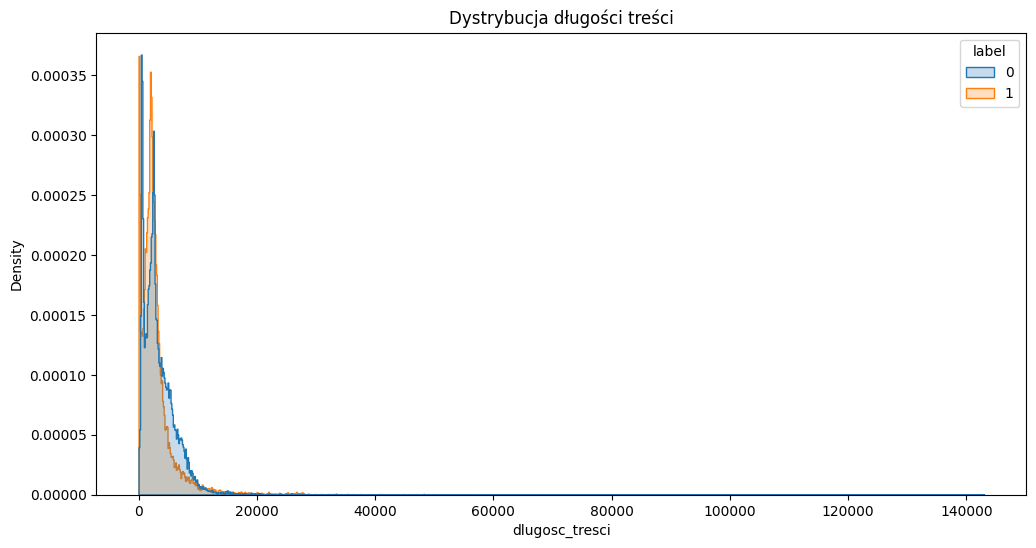

In [4]:
# Stworzenie nowych kolumn z długością (liczbą znaków)
df['dlugosc_tytulu'] = df['title'].str.len()
df['dlugosc_tresci'] = df['text'].str.len()

# Wykresy, aby porównać dystrybucje
plt.figure(figsize=(12, 6))

# Histogram dla długości tytułu
sns.histplot(data=df, x='dlugosc_tytulu', hue='label', element='step', stat='density', common_norm=False)
plt.title('Dystrybucja długości tytułów')
plt.show()

plt.figure(figsize=(12, 6))

# Histogram dla długości treści
sns.histplot(data=df, x='dlugosc_tresci', hue='label', element='step', stat='density', common_norm=False)
plt.title('Dystrybucja długości treści')
plt.show()

Możemy zauważyc delikatne przesunięcie w dystrybucji długości tutłow i teksstów. Podsumowując:


1.   FAKE NEWS - długi tytuł, krótka treść
2.   REAL NEWS - krótki tytuł, długa treść



In [5]:
import re
import string
from collections import Counter
from wordcloud import STOPWORDS
def czysc_tekst(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text
df['cleaned_text'] = df['text'].apply(czysc_tekst)

tekst_fake = " ".join(df[df['label'] == 1]['cleaned_text'])
tekst_real = " ".join(df[df['label'] == 0]['cleaned_text'])

#  Zliczanie i wypisywanie słów

def wypisz_najczestsze_slowa(tekst, kategoria, liczba_slow=20):
    """
    Funkcja zlicza i wypisuje najczęstsze słowa w danym tekście.
    """
    slowa = tekst.split()
    # Usuń popularne słowa (stop words)
    slowa_bez_stop = [slowo for slowo in slowa if slowo not in STOPWORDS]

    # Zlicz wystąpienia każdego słowa
    licznik = Counter(slowa_bez_stop)

    #  Wypisz nagłówek i 20 najczęstszych słów
    print(f"--- 20 najczęstszych słów w kategorii: {kategoria} ---")
    for slowo, ilosc in licznik.most_common(liczba_slow):
        print(f"{slowo}: {ilosc}")
    print("\n")

# Wywołanie funkcji
wypisz_najczestsze_slowa(tekst_fake, "Fake News")
wypisz_najczestsze_slowa(tekst_real, "Real News")

--- 20 najczęstszych słów w kategorii: Fake News ---
s: 129603
trump: 95489
will: 53098
us: 48595
said: 46833
people: 46516
one: 42532
t: 40950
clinton: 39264
president: 35401
hillary: 28846
new: 27686
obama: 25971
now: 25548
even: 25281
donald: 24117
time: 23971
state: 23094
news: 20759
many: 20108


--- 20 najczęstszych słów w kategorii: Real News ---
said: 183734
trump: 81652
mr: 65710
will: 52251
us: 51282
s: 50289
”: 46455
president: 45897
—: 44711
new: 41258
one: 40100
people: 38813
state: 34271
states: 30554
reuters: 28614
government: 27909
house: 27654
united: 27509
last: 26172
two: 26157




Możemy zauważyć że w fake newsach występuje Silna koncentracja na osobach. Lista jest zdominowana przez nazwiska i imiona konkretnych polityków. Aż 6 z 20 najczęstszych słów.

Z drugiej stronych jezli w teksicie język jest bardziej folrmany i powoływany jest na instytucja. To istniej większa szansa że jest on prawdziwy. Dotyczy  też to tekstów które powołująsię na agencje wydawniczą np. reuteres

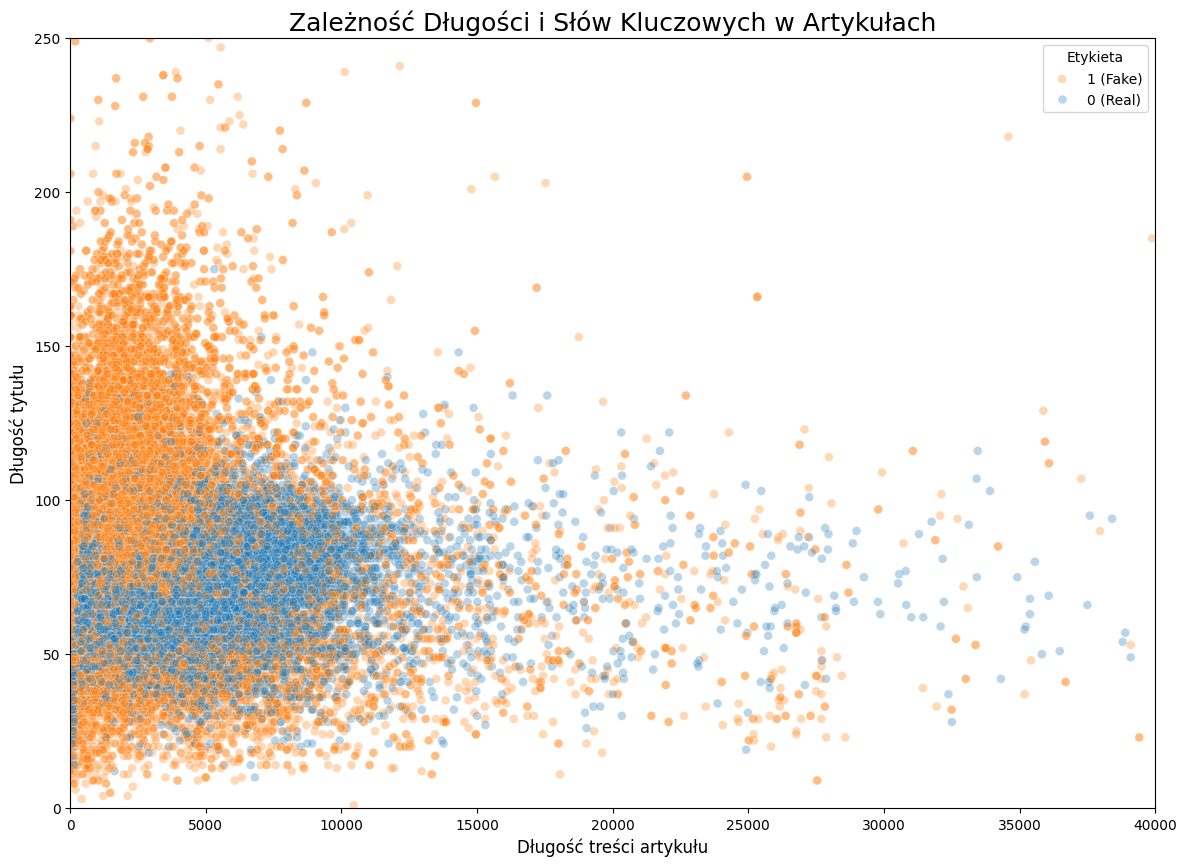

In [8]:
#Funkcja pomocnicza do ekstrakcji słów kluczowych
def get_top_keywords(text, n=5):
    """Wyciąga n najczęstszych słów z pojedynczego tekstu."""
    if not isinstance(text, str):
        return []
    words = text.lower().split()
    words_no_stopwords = [word for word in words if word not in STOPWORDS and len(word) > 2]
    return [word for word, count in Counter(words_no_stopwords).most_common(n)]

#FAKE NEWS
fake_example = df[(df['label'] == 1) & (df['dlugosc_tresci'] < 2000)].nlargest(1, 'dlugosc_tytulu')
#REAL NEWS
real_example = df[(df['label'] == 0) & (df['dlugosc_tytulu'] < 100)].nlargest(1, 'dlugosc_tresci')

#Generowanie wykresu
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df, x='dlugosc_tresci', y='dlugosc_tytulu',
    hue='label', alpha=0.3, s=40
)

# Adnotacja dla FAKE NEWS
if not fake_example.empty:
    # Pobranie danych punktu
    fake_point = fake_example.iloc[0]
    x = fake_point['dlugosc_tresci']
    y = fake_point['dlugosc_tytulu']
    keywords = get_top_keywords(fake_point['cleaned_text'])

    # Stworzenie tekstu adnotacji
    annotation_text = f"Typowy Fake News\nSłowa kluczowe:\n- {keywords[0]}\n- {keywords[1]}\n- {keywords[2]}"

    # Dodanie adnotacji do wykresu
    plt.annotate(annotation_text, xy=(x, y), xytext=(x + 5000, y + 20),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 bbox=dict(boxstyle="round,pad=0.5", fc="orange", ec="black", lw=1, alpha=0.8))

# Adnotacja dla REAL NEWS
if not real_example.empty:
    # Pobranie danych punktu
    real_point = real_example.iloc[0]
    x = real_point['dlugosc_tresci']
    y = real_point['dlugosc_tytulu']
    keywords = get_top_keywords(real_point['cleaned_text'])
    annotation_text = f"Typowy Real News\nSłowa kluczowe:\n- {keywords[0]}\n- {keywords[1]}\n- {keywords[2]}"
    plt.annotate(annotation_text, xy=(x, y), xytext=(x - 20000, y + 50),
                 arrowprops=dict(facecolor='blue', shrink=0.05),
                 bbox=dict(boxstyle="round,pad=0.5", fc="lightblue", ec="black", lw=1, alpha=0.8))


# Ustawienia końcowe wykresu
plt.title('Zależność Długości i Słów Kluczowych w Artykułach', fontsize=18)
plt.xlabel('Długość treści artykułu', fontsize=12)
plt.ylabel('Długość tytułu', fontsize=12)
plt.legend(title='Etykieta', labels=['1 (Fake)', '0 (Real)'])
plt.xlim(0, 40000)
plt.ylim(0, 250)

plt.show()

# **Wnioski:**

1.   **Fake News**

*  Lokalizacja: Głównie w lewym górnym rogu wykresu (ta strefa reprezentuje artykuły, które mają długie tytuły i krótką treść).
*   To wizualny dowód na strategię clickbaitu. To tutaj znajdują się artykuły, których słowami kluczowymi są nazwiska polityków i emocjonalne hasła.


2.  **Real News**

*   Lokalizacja: Głównie w dolnej części wykresu, rozciągając się w prawo. (mają krótkie tytuł, ale ich treść jest zróżnicowana i często bardzo długa)
*   To idealnie pasuje do stylu rzetelnego dziennikarstwa. Tytuł jest zwięzły i informacyjny, a treść jest rozbudowana, ponieważ zawiera kontekst, cytaty i szczegółową analizę.


3. **strefa zmieszana do której nie mamy pewności**

*   Lokalizacja: W lewym dolnym rogu. (W tym obszarze znajdują się zarówno prawdziwe, jak i fałszywe wiadomości, które mają jednocześnie krótki tytuł i krótką treść)
*   W tej strefie cechy takie jak długość tytułu i treści nie wystarczą do poprawnej klasyfikacji. Właśnie tutaj model będzie musiał polegać na analizie słów kluczowych.





